# Kelompok KBS

- Nanda Mayla Adiasti (103132400003)
- Andita Ayuningtyas (103132400016)
- Gendis Pambayun (103132400031)
- Humairah Nurhamidah (103132400038)
- Nisa (103132400044)

IMPORT LIBRARY

In [ ]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

UPLOAD DAN BACA DATASET

In [ ]:
# ==========================================
# MEMBACA DATASET
# ==========================================

from google.colab import files
uploaded = files.upload()

Saving dataset_final.csv to dataset_final.csv


In [ ]:
# ==========================================
# MEMBACA FILE CSV
# ==========================================

file_name = 'dataset_final.csv'

# membaca dataset
_df = pd.read_csv(file_name)

# menampilkan 5 data pertama
_df.head()

,harga,tanggal,hari_ke
0,771000,2020-01-02 07:26:40,0
1,775000,2020-01-03 08:26:40,1
2,783000,2020-01-04 06:40:00,2
3,792000,2020-01-06 08:40:00,3
4,793000,2020-01-07 09:40:00,4


CEK INFO DATASET

In [ ]:
_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   harga    2050 non-null   int64 
 1   tanggal  2050 non-null   object
 2   hari_ke  2050 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 48.2+ KB


UBAH FORMAT TANGGAL

In [ ]:
# ==========================================
# KONVERSI FORMAT TANGGAL
# ==========================================

_df['tanggal'] = pd.to_datetime(_df['tanggal'])

# urutkan berdasarkan tanggal
_df = _df.sort_values('tanggal')

# reset index
_df = _df.reset_index(drop=True)

_df.head()

,harga,tanggal,hari_ke
0,771000,2020-01-02 07:26:40,0
1,775000,2020-01-03 08:26:40,1
2,783000,2020-01-04 06:40:00,2
3,792000,2020-01-06 08:40:00,3
4,793000,2020-01-07 09:40:00,4


AMBIL DATA TAHUN 2023-2025

In [ ]:
# ==========================================
# FILTER DATA 2023 - 2025
# ==========================================

_df = _df[
    (_df['tanggal'].dt.year >= 2023) &
    (_df['tanggal'].dt.year <= 2025)
]

_df.tail()

,harga,tanggal,hari_ke
2045,2235000,2025-10-02 07:26:40,2045
2046,2235000,2025-10-03 08:26:40,2046
2047,2239000,2025-10-04 09:26:40,2047
2048,2250000,2025-10-06 08:40:00,2048
2049,2284000,2025-10-07 06:53:20,2049


Membuat Fitur Numerik untuk Machine Learning

In [ ]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# membuat fitur numerik berdasarkan urutan hari
_df['hari_ke'] = (_df['tanggal'] - _df['tanggal'].min()).dt.days

# harga 1 hari sebelumnya
_df['lag_1'] = _df['harga'].shift(1)

# harga 7 hari sebelumnya
_df['lag_7'] = _df['harga'].shift(7)

# rata-rata harga 7 hari
_df['rolling_mean_7'] = (
    _df['harga']
    .rolling(window=7)
    .mean()
)

# rata-rata harga 30 hari
_df['rolling_mean_30'] = (
    _df['harga']
    .rolling(window=30)
    .mean()
)

# hapus data kosong akibat shifting
_df = _df.dropna()

_df.head()

,harga,tanggal,hari_ke,lag_1,lag_7,rolling_mean_7,rolling_mean_30
1058,1029000,2023-01-30 09:13:20,29,1029000.0,1035000.0,1.032714e+06,1.032633e+06
1059,1027000,2023-01-31 07:26:40,29,1029000.0,1037000.0,1.031286e+06,1.032667e+06
1060,1029000,2023-02-01 08:26:40,31,1027000.0,1040000.0,1.029714e+06,1.032767e+06
1061,1042000,2023-02-02 09:26:40,32,1029000.0,1035000.0,1.030714e+06,1.033433e+06
1062,1029000,2023-02-03 07:40:00,32,1042000.0,1030000.0,1.030571e+06,1.033600e+06


TENTUKAN VARIABEL X DAN Y

In [ ]:
# ==========================================
# MENENTUKAN FITUR DAN TARGET
# ==========================================

X = _df[[
    'hari_ke',
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'rolling_mean_30'
]]

y = _df['harga']

SPLIT DATA TRAIN DAN TEST

In [ ]:
# ==========================================
# SPLIT TRAIN TEST
# ==========================================

split_index = int(len(_df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print('Jumlah data train :', len(X_train))
print('Jumlah data test  :', len(X_test))

Jumlah data train : 793
Jumlah data test  : 199


MEMBUAT MODEL LINEAR REGRESSION

In [ ]:
# ==========================================
# MODEL LINEAR REGRESSION
# ==========================================

linear_model = LinearRegression()

# training model
linear_model.fit(X_train, y_train)

# prediksi
linear_predictions = linear_model.predict(X_test)

EVALUASI MODEL LINEAR REGRESSION

In [ ]:
# ==========================================
# EVALUASI MODEL LINEAR
# ==========================================

mae_linear = mean_absolute_error(y_test, linear_predictions)
rmse_linear = np.sqrt(mean_squared_error(y_test, linear_predictions))
r2_linear = r2_score(y_test, linear_predictions)

print('===== HASIL LINEAR REGRESSION =====')
print(f'MAE  : {mae_linear:,.2f}')
print(f'RMSE : {rmse_linear:,.2f}')
print(f'R2   : {r2_linear:.4f}')

===== HASIL LINEAR REGRESSION =====
MAE  : 11,820.81
RMSE : 15,709.49
R2   : 0.9712


MEMBUAT MODEL POLYNOMINAL REGRESSION

In [ ]:
# ==========================================
# MODEL POLYNOMIAL REGRESSION
# ==========================================

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

# training
poly_model.fit(X_train, y_train)

# prediksi
poly_predictions = poly_model.predict(X_test)

EVALUASI POLYNOMINAL REGRESSION

In [ ]:
# ==========================================
# EVALUASI POLYNOMIAL REGRESSION
# ==========================================

mae_poly = mean_absolute_error(y_test, poly_predictions)
rmse_poly = np.sqrt(mean_squared_error(y_test, poly_predictions))
r2_poly = r2_score(y_test, poly_predictions)

print('===== HASIL POLYNOMIAL REGRESSION =====')
print(f'MAE  : {mae_poly:,.2f}')
print(f'RMSE : {rmse_poly:,.2f}')
print(f'R2   : {r2_poly:.4f}')

===== HASIL POLYNOMIAL REGRESSION =====
MAE  : 24,259.62
RMSE : 33,832.18
R2   : 0.8663


PERBANDINGAN KEDUA MODEL

In [ ]:
# ==========================================
# PERBANDINGAN MODEL
# ==========================================

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression'],
    'MAE': [mae_linear, mae_poly],
    'RMSE': [rmse_linear, rmse_poly],
    'R2': [r2_linear, r2_poly]
})
#hasil
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,11820.808607,15709.490361,0.971176
1,Polynomial Regression,24259.623098,33832.175817,0.866313


VISUALISASI HASIL PREDIKSI

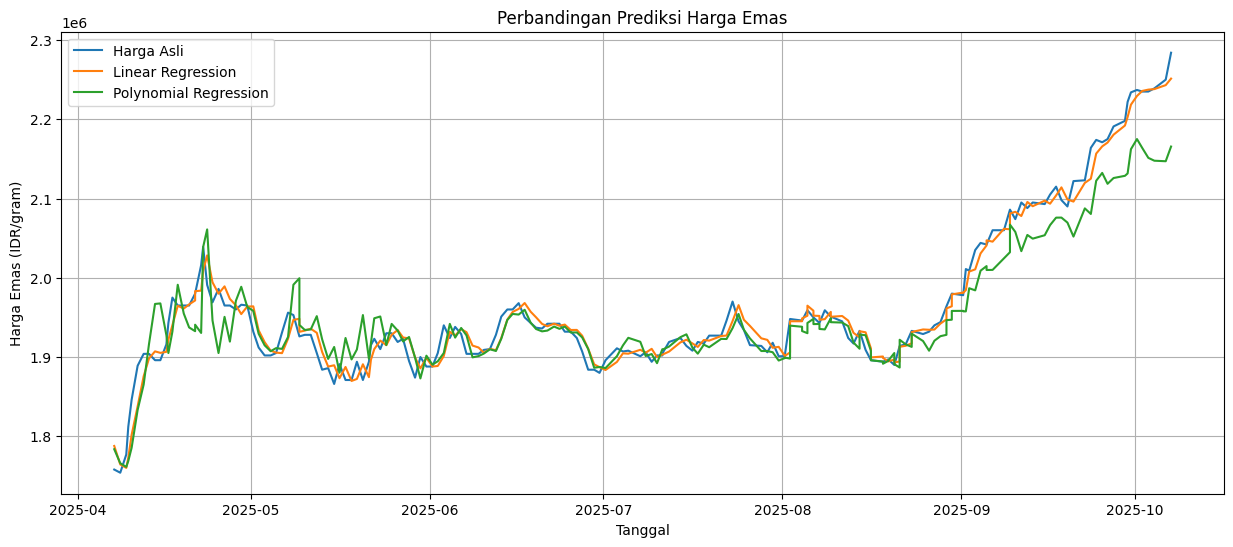

In [ ]:
# ==========================================
# VISUALISASI HASIL
# ==========================================

plt.figure(figsize=(15,6))

# data asli
plt.plot(
    _df['tanggal'].iloc[split_index:],
    y_test.values,
    label='Harga Asli'
)

# linear regression
plt.plot(
    _df['tanggal'].iloc[split_index:],
    linear_predictions,
    label='Linear Regression'
)

# polynomial regression
plt.plot(
    _df['tanggal'].iloc[split_index:],
    poly_predictions,
    label='Polynomial Regression'
)

plt.title('Perbandingan Prediksi Harga Emas')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas (IDR/gram)')
plt.legend()
plt.grid(True)

plt.show()

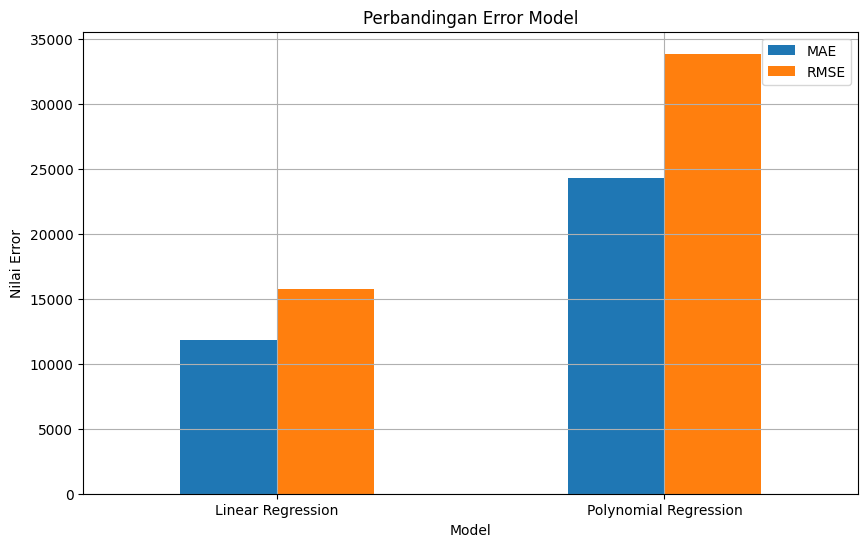

In [ ]:
# ==========================================
# VISUALISASI EVALUASI MODEL
# ==========================================

comparison_plot = comparison.set_index('Model')

comparison_plot[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Perbandingan Error Model')
plt.ylabel('Nilai Error')
plt.xticks(rotation=0)

plt.grid(True)

plt.show()

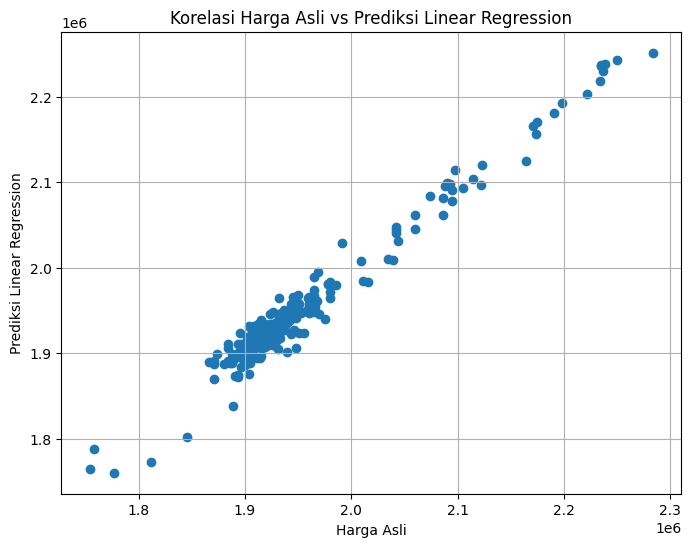

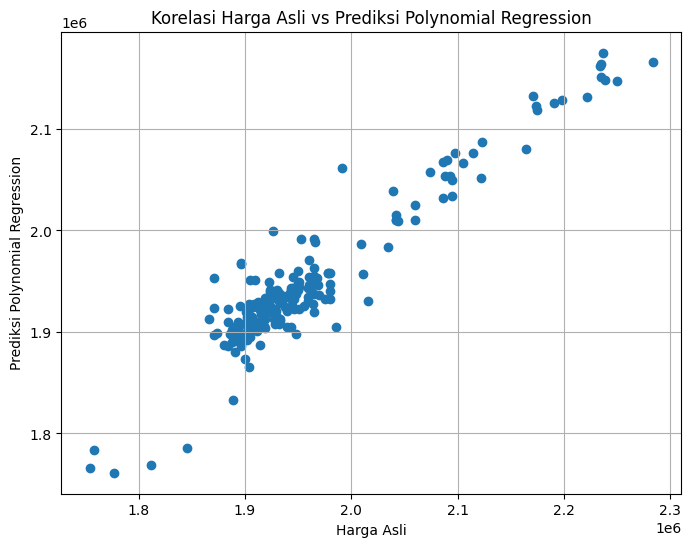

In [ ]:
# ==========================================
# KORELASI LINEAR REGRESSION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions
)

plt.xlabel('Harga Asli')
plt.ylabel('Prediksi Linear Regression')

plt.title(
    'Korelasi Harga Asli vs Prediksi Linear Regression'
)

plt.grid(True)

plt.show()

# ==========================================
# KORELASI POLYNOMIAL REGRESSION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    poly_predictions
)

plt.xlabel('Harga Asli')

plt.ylabel(
    'Prediksi Polynomial Regression'
)

plt.title(
    'Korelasi Harga Asli vs Prediksi Polynomial Regression'
)

plt.grid(True)

plt.show()

PREDIKSI HARGA MASA DEPAN

In [ ]:
# ==========================================
# PREDIKSI MASA DEPAN
# ==========================================

future_days = 90

# ambil data terakhir
last_row = _df.iloc[-1]

last_days = last_row['hari_ke']
last_price = last_row['harga']

# membuat list hasil prediksi
future_results = []

# nilai awal
lag_1 = last_row['lag_1']
lag_7 = last_row['lag_7']

rolling_mean_7 = last_row['rolling_mean_7']
rolling_mean_30 = last_row['rolling_mean_30']

current_price = last_price

# looping prediksi masa depan
for i in range(1, future_days + 1):

    future_day = last_days + i

    future_input = pd.DataFrame({
        'hari_ke': [future_day],
        'lag_1': [current_price],
        'lag_7': [lag_7],
        'rolling_mean_7': [rolling_mean_7],
        'rolling_mean_30': [rolling_mean_30]
    })

    # prediksi
    future_price = linear_model.predict(
        future_input
    )[0]

    # simpan hasil
    future_results.append(future_price)

    # update harga
    current_price = future_price

# membuat tanggal masa depan
future_dates = pd.date_range(
    start=_df['tanggal'].max() + pd.Timedelta(days=1),
    periods=future_days
)

# dataframe hasil prediksi
future_df = pd.DataFrame({
    'Tanggal': future_dates,
    'Prediksi_Harga': future_results
})

future_df.head()

,Tanggal,Prediksi_Harga
0,2025-10-08 06:53:20,2.275625e+06
1,2025-10-09 06:53:20,2.269652e+06
2,2025-10-10 06:53:20,2.265394e+06
3,2025-10-11 06:53:20,2.262361e+06
4,2025-10-12 06:53:20,2.260202e+06


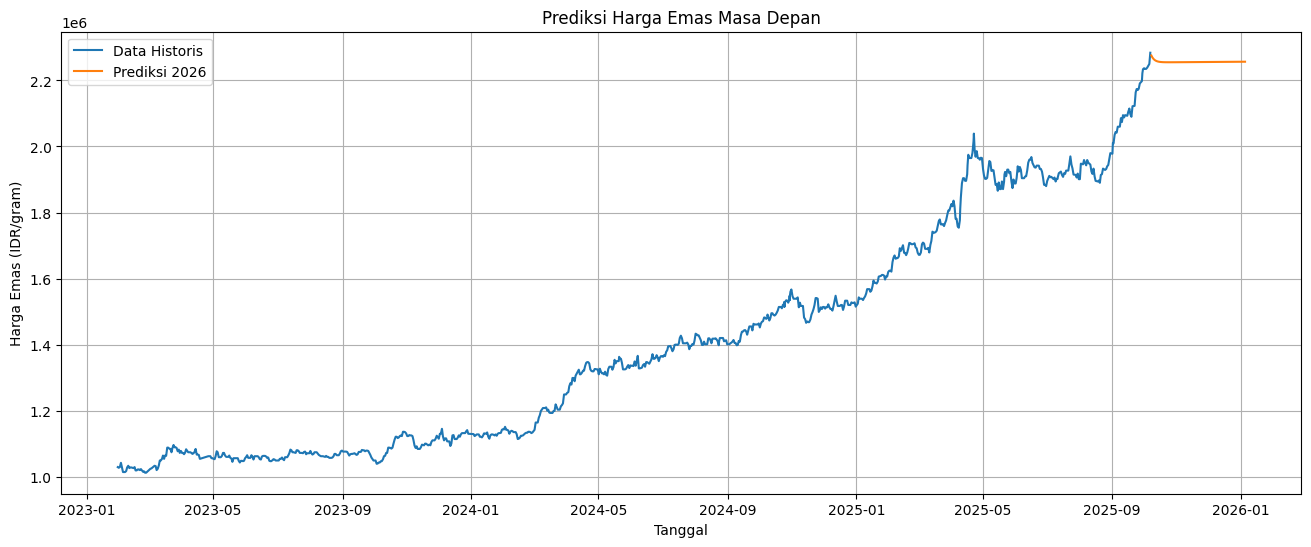

In [ ]:
# ==========================================
# VISUALISASI PREDIKSI MASA DEPAN
# ==========================================

plt.figure(figsize=(16,6))

# data historis
plt.plot(
    _df['tanggal'],
    _df['harga'],
    label='Data Historis'
)

# prediksi masa depan
plt.plot(
    future_df['Tanggal'],
    future_df['Prediksi_Harga'],
    label='Prediksi 2026'
)

plt.title('Prediksi Harga Emas Masa Depan')

plt.xlabel('Tanggal')
plt.ylabel('Harga Emas (IDR/gram)')

plt.legend()

plt.grid(True)

plt.show()